In [1]:
import sys
from matplotlib import pyplot as plt
from sklift.metrics import uplift_at_k
import seaborn as sns
import numpy as np
import pandas as pd
import joblib
from sklift.models import ClassTransformation
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier
from sklift.metrics import qini_auc_score

# install uplift library scikit-uplift and other libraries
#!{sys.executable} -m pip install scikit-uplift dill catboost

# %config InlineBackend.figure_format = 'svg'
# %matplotlib inline

## Input dataset

In [2]:
#dataset = joblib.load("data/hillstrom.joblib")

In [3]:
#dataset.keys()

In [4]:
# # 1. Start by merging everything into one Master DataFrame
# # Assuming dataset.data is a pandas DataFrame or similar-structured object
# df_input = pd.DataFrame(dataset.data)

# # 2. Add your columns
# df_input['treatment'] = dataset.treatment # Note: or whatever your source for the treatment col is
# df_input[dataset.target.columns] = dataset.target

In [5]:
#df_input.to_parquet('data/hillstrom.parquet', index=False)

In [6]:
df_input=pd.read_parquet('data/hillstrom.parquet')
# Exclude target columns using for prediction 
target_cols = ['treatment', 'visit', 'conversion','spend']

In [7]:
df_input.head(20)

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


### Feature leakage check

In [8]:
pd.DataFrame(df_input[['mens','womens','treatment','visit']].value_counts(dropna=False)).reset_index()

,mens,womens,treatment,visit,count
0,1,0,No E-Mail,0,8676
1,0,1,No E-Mail,0,8607
2,1,0,Womens E-Mail,0,8555
3,0,1,Womens E-Mail,0,8009
4,0,1,Mens E-Mail,0,7976
5,1,0,Mens E-Mail,0,7943
6,1,1,No E-Mail,0,1761
7,0,1,Womens E-Mail,1,1638
8,1,0,Mens E-Mail,1,1615
9,0,1,Mens E-Mail,1,1592


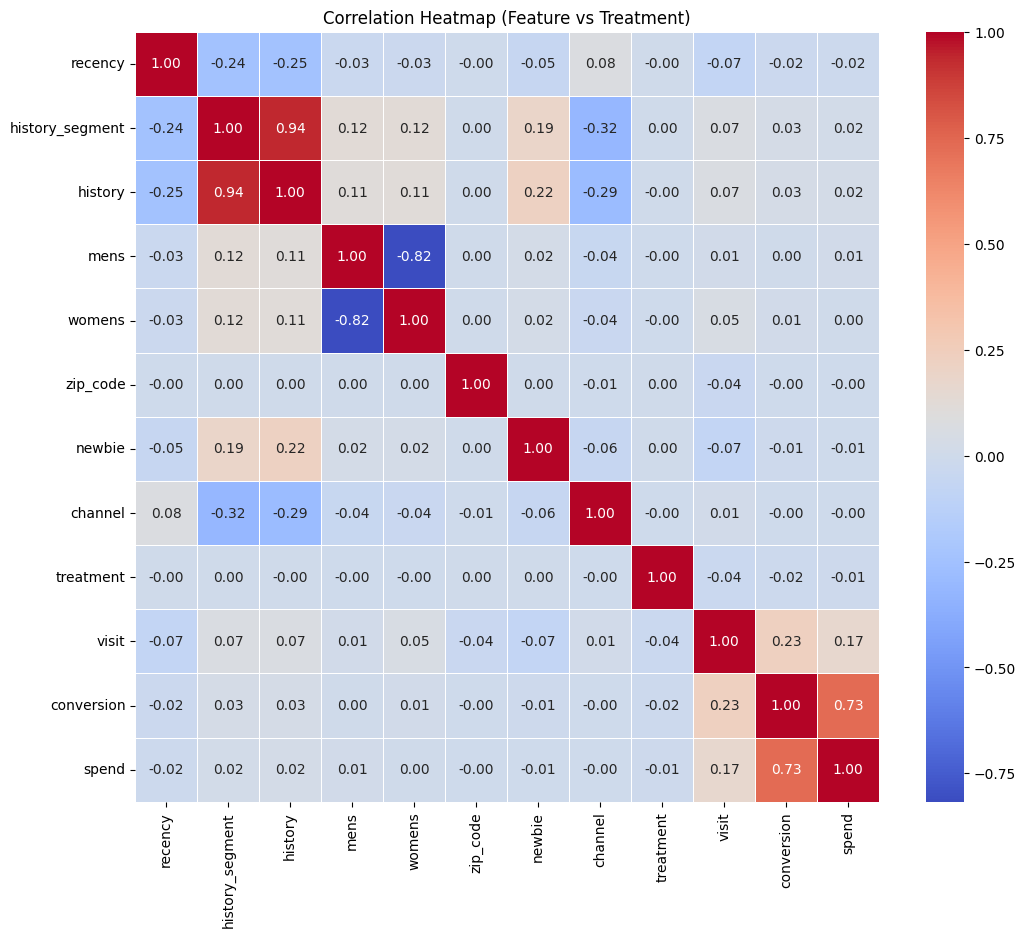

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a copy for the heatmap
# We convert everything to numeric so we can calculate correlations
corr_df = df_input.copy()

# 2. Encode categorical columns to numeric
# 'treatment' must be encoded: Womens E-Mail=2, Mens E-Mail=1, No E-Mail=0
#corr_df['treatment'] = corr_df['treatment'].map({'Womens E-Mail': 2, 'Mens E-Mail': 1, 'No E-Mail': 0})

# Encode others: Zip_Code, Channel, History_Segment
cat_cols = ['zip_code', 'channel', 'history_segment','treatment']
for col in cat_cols:
    corr_df[col] = corr_df[col].astype('category').cat.codes

# 3. Calculate Correlation Matrix
corr_matrix = corr_df.corr()

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Feature vs Treatment)")
plt.show()

In [10]:
df_input.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'treatment', 'visit', 'conversion', 'spend'],
      dtype='object')

## Men Modelling 
Filter out Women E-mail treatment

In [11]:
df_men=df_input[df_input['treatment']!='Womens E-Mail']

In [12]:
df_men.shape

(42613, 12)

In [13]:
df_men['treatment'].value_counts()

treatment
Mens E-Mail    21307
No E-Mail      21306
Name: count, dtype: int64

In [14]:
treatment_map = {'No E-Mail': 0, 'Mens E-Mail': 1}
df_men['treatment'] = df_men['treatment'].map(treatment_map)

C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_27216\4169295510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_men['treatment'] = df_men['treatment'].map(treatment_map)


In [15]:
df_men['treatment'].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

In [16]:
df_men

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,1,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,1,0,0,0.0
13,2,2) $100 - $200,101.64,0,1,Urban,0,Web,1,1,0,0.0
14,4,3) $200 - $350,241.42,0,1,Rural,1,Multichannel,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63994,7,1) $0 - $100,86.46,0,1,Urban,0,Web,1,0,0,0.0
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,1,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,1,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,1,0,0,0.0


In [17]:
pd.pivot_table(df_men, index='treatment',columns='visit', values='recency', aggfunc=['mean','count' ])

mean            count      
visit             0         1      0     1
treatment                                 
0          5.849874  4.906278  19044  2262
1          5.906736  5.178480  17413  3894

In [18]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([df_men['treatment'], df_men['visit']], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    df_men.drop(columns=target_cols),
    df_men['treatment'],
    df_men['visit'],
    stratify=stratify_cols,
    test_size=0.3,
    random_state=41
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (29829, 8)
Validation shape: (12784, 8)


In [19]:
z_val = np.where((trmnt_val == 1) & (y_val == 1), 1,
          np.where((trmnt_val == 0) & (y_val == 0), 1, 0))

In [20]:
estimator = CatBoostClassifier(
    iterations=1000,          # Allow up to 1000, but early stopping will cut it short
    learning_rate=0.03,       # Slower is safer (standard for CatBoost)
    depth=4,                  # VERY IMPORTANT: Keep between 3 and 5. Deep trees memorize noise.
    l2_leaf_reg=10,           # Higher values (e.g., 10-20) force the model to be simpler
    min_data_in_leaf=50,      # Force each tree leaf to represent at least 50 users
    random_strength=1,        # Prevents tree from overfitting to specific training samples
    
    # Early Stopping
    early_stopping_rounds=50,
    
    # Categorical handling
    cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
    
    # Misc
    random_state=42,
    thread_count=1,
    verbose=50                # Print less often to keep your console clean
)

ct_model = ClassTransformation(estimator=estimator)

In [21]:
ct_model.fit(
    X=X_train, y=y_train, treatment=trmnt_train,
    estimator_fit_params={'eval_set': (X_val, z_val),'early_stopping_rounds': 50} # Now the model has eyes!
)

0:	learn: 0.6929719	test: 0.6929743	best: 0.6929743 (0)	total: 177ms	remaining: 2m 56s
50:	learn: 0.6900793	test: 0.6903122	best: 0.6903122 (50)	total: 1.76s	remaining: 32.7s
100:	learn: 0.6896770	test: 0.6901818	best: 0.6901740 (98)	total: 3.24s	remaining: 28.8s
150:	learn: 0.6893836	test: 0.6901755	best: 0.6901687 (135)	total: 4.78s	remaining: 26.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6901687401
bestIteration = 135

Shrink model to first 136 iterations.


,estimator,"CatBoostClass...1, verbose=50)"


In [22]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from sklift.metrics import uplift_at_k
from catboost import CatBoostClassifier
from sklift.models import ClassTransformation

# 1. Define X, y, t
X = df_men.drop(columns=target_cols)
y = df_men['visit']
t = df_men['treatment']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
results = []
trained_models = []


for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Slice the data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    t_train_fold, t_val_fold = t.iloc[train_index], t.iloc[val_index]
    
    # Generate the Z-label
    z_train_fold = np.where((t_train_fold == 1) & (y_train_fold == 1), 1,
                     np.where((t_train_fold == 0) & (y_train_fold == 0), 1, 0))
    z_val_fold = np.where((t_val_fold == 1) & (y_val_fold == 1), 1,
                   np.where((t_val_fold == 0) & (y_val_fold == 0), 1, 0))
    
    # Initialize and Fit
    estimator = CatBoostClassifier(
        iterations=1000, depth=4, learning_rate=0.05,
        cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
        early_stopping_rounds=50, random_state=42, thread_count=1, verbose=0
    )
    
    ct_model = ClassTransformation(estimator=estimator)
    
    ct_model.fit(
        X_train_fold, y_train_fold, treatment=t_train_fold,
        estimator_fit_params={
            'eval_set': (X_val_fold, z_val_fold),
            'early_stopping_rounds': 50
        }
    )
    
    # Predict
    train_preds = ct_model.predict(X_train_fold)
    val_preds = ct_model.predict(X_val_fold)
    
    # Score
    train_score = uplift_at_k(y_train_fold, train_preds, t_train_fold, strategy='overall', k=0.1)
    val_score = uplift_at_k(y_val_fold, val_preds, t_val_fold, strategy='overall', k=0.1)
    
    results.append({
        "Fold": fold + 1,
        "Train Uplift": train_score,
        "Validation Uplift": val_score
    })

    trained_models.append(ct_model)


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Add average row
avg_row = pd.DataFrame({
    "Fold": ["Average"],
    "Train Uplift": [results_df["Train Uplift"].mean()],
    "Validation Uplift": [results_df["Validation Uplift"].mean()]
})

results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df)

      Fold  Train Uplift  Validation Uplift
0        1      0.147433           0.092478
1        2      0.126529           0.126924
2        3      0.143785           0.131933
3        4      0.128955           0.120019
4        5      0.126378           0.078133
5  Average      0.134616           0.109897


In [23]:
ct_model=trained_models[2]

In [24]:
## Save model
joblib.dump(ct_model, 'models/mens_uplift_model.pkl')

['models/mens_uplift_model.pkl']

In [25]:
# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model.predict(X_train)
val_preds = ct_model.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): 0.0274
Qini Score (Validation): 0.0403


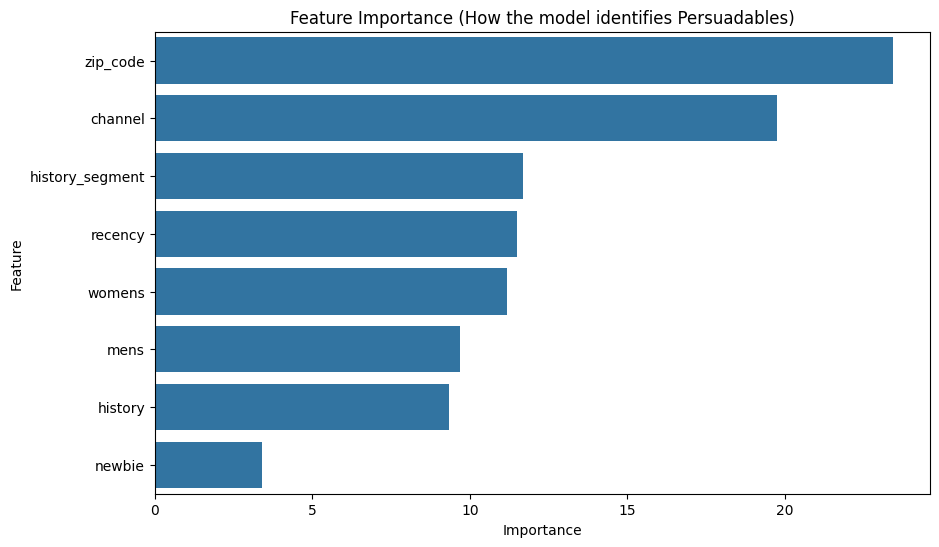

           Feature  Importance
5         zip_code   23.429206
7          channel   19.765235
1  history_segment   11.678210
0          recency   11.504263
4           womens   11.173855
3             mens    9.704209
2          history    9.326663
6           newbie    3.418359


In [26]:
# 1. Get the underlying estimator
# This is the trained CatBoost model
fitted_estimator = ct_model.estimator

# 2. Get the feature importances
# CatBoost provides 'feature_importances_'
importances = fitted_estimator.feature_importances_

# 3. Create a clean DataFrame for viewing
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance (How the model identifies Persuadables)")
plt.show()

print(importance_df)

In [27]:
from sklift.metrics import uplift_at_k
import pandas as pd

k = 0.1

# 1. Calculate for TOP 10% (Using original predictions)
top_train_overall = uplift_at_k(y_train, train_preds, trmnt_train, strategy='overall', k=k)
top_val_overall = uplift_at_k(y_val, val_preds, trmnt_val, strategy='overall', k=k)

# 2. Calculate for BOTTOM 10% (By flipping the sign of the predictions)
# By multiplying by -1, the "lowest" scores become the "highest"
bot_train_overall = uplift_at_k(y_train, -train_preds, trmnt_train, strategy='overall', k=k)
bot_val_overall = uplift_at_k(y_val, -val_preds, trmnt_val, strategy='overall', k=k)

# 3. Create the comparison table
results_df = pd.DataFrame({
    "Segment": ["Top 10% (Original)", "Bottom 10% (Flipped)"],
    "Train Uplift": [top_train_overall, bot_train_overall],
    "Validation Uplift": [top_val_overall, bot_val_overall]
})

print(results_df)

                Segment  Train Uplift  Validation Uplift
0    Top 10% (Original)      0.140156           0.153824
1  Bottom 10% (Flipped)      0.076630           0.049085


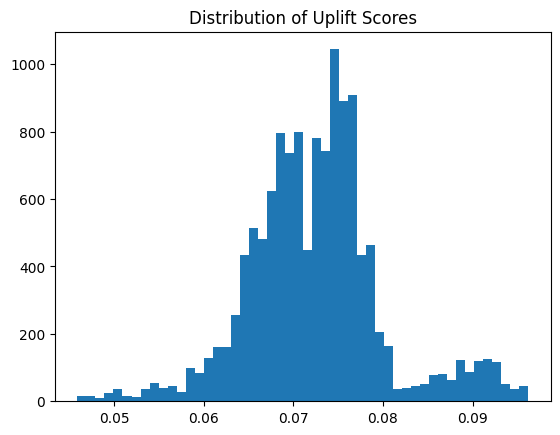

In [28]:
import matplotlib.pyplot as plt
plt.hist(val_preds, bins=50)
plt.title("Distribution of Uplift Scores")
plt.show()

## Women Modelling 
Filter out Men E-mail treatment

In [29]:
df_women=df_input[df_input['treatment']!='Mens E-Mail']

In [30]:
df_women.shape

(42693, 12)

In [31]:
df_women

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63989,10,3) $200 - $350,304.30,1,1,Surburban,0,Web,Womens E-Mail,1,0,0.0
63990,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone,No E-Mail,0,0,0.0
63991,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
63993,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone,Womens E-Mail,0,0,0.0


In [32]:
df_women['treatment'].value_counts()

treatment
Womens E-Mail    21387
No E-Mail        21306
Name: count, dtype: int64

In [33]:
treatment_map = {'No E-Mail': 0, 'Womens E-Mail': 1}
df_women['treatment'] = df_women['treatment'].map(treatment_map)


C:\Users\vncpyy7h\AppData\Local\Temp\ipykernel_27216\2065503433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_women['treatment'] = df_women['treatment'].map(treatment_map)


In [34]:
df_women['treatment'].value_counts()

treatment
1    21387
0    21306
Name: count, dtype: int64

In [35]:
df_women

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,1,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,1,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,1,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,1,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63989,10,3) $200 - $350,304.30,1,1,Surburban,0,Web,1,1,0,0.0
63990,6,1) $0 - $100,80.02,0,1,Surburban,0,Phone,0,0,0,0.0
63991,1,3) $200 - $350,306.10,1,0,Surburban,1,Phone,1,0,0,0.0
63993,4,4) $350 - $500,374.07,0,1,Surburban,0,Phone,1,0,0,0.0


In [36]:
pd.pivot_table(df_women, index='treatment',columns='visit', values='recency', aggfunc=['mean','count' ])

mean            count      
visit             0         1      0     1
treatment                                 
0          5.849874  4.906278  19044  2262
1          5.863408  5.232242  18149  3238

In [37]:
from sklearn.model_selection import train_test_split

stratify_cols = pd.concat([df_women['treatment'], df_women['visit']], axis=1)

X_train, X_val, trmnt_train, trmnt_val, y_train, y_val = train_test_split(
    df_women.drop(columns=target_cols),
    df_women['treatment'],
    df_women['visit'],
    stratify=stratify_cols,
    test_size=0.3,
    random_state=41
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Train shape: (29885, 8)
Validation shape: (12808, 8)


In [38]:
z_val = np.where((trmnt_val == 1) & (y_val == 1), 1,
          np.where((trmnt_val == 0) & (y_val == 0), 1, 0))

In [39]:
estimator = CatBoostClassifier(
    iterations=1000,          # Allow up to 1000, but early stopping will cut it short
    learning_rate=0.03,       # Slower is safer (standard for CatBoost)
    depth=4,                  # VERY IMPORTANT: Keep between 3 and 5. Deep trees memorize noise.
    l2_leaf_reg=10,           # Higher values (e.g., 10-20) force the model to be simpler
    min_data_in_leaf=50,      # Force each tree leaf to represent at least 50 users
    random_strength=1,        # Prevents tree from overfitting to specific training samples
    
    # Early Stopping
    early_stopping_rounds=50,
    
    # Categorical handling
    cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
    
    # Misc
    random_state=42,
    thread_count=1,
    verbose=50                # Print less often to keep your console clean
)

ct_model = ClassTransformation(estimator=estimator)

In [40]:
ct_model.fit(
    X=X_train, y=y_train, treatment=trmnt_train,
    estimator_fit_params={'eval_set': (X_val, z_val),'early_stopping_rounds': 50} # Now the model has eyes!
)

0:	learn: 0.6930517	test: 0.6930682	best: 0.6930682 (0)	total: 38.1ms	remaining: 38s
50:	learn: 0.6915631	test: 0.6919447	best: 0.6919447 (50)	total: 1.67s	remaining: 31.1s
100:	learn: 0.6911433	test: 0.6918451	best: 0.6918429 (96)	total: 3.35s	remaining: 29.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6918428834
bestIteration = 96

Shrink model to first 97 iterations.


,estimator,"CatBoostClass...1, verbose=50)"


In [41]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from sklift.metrics import uplift_at_k
from catboost import CatBoostClassifier
from sklift.models import ClassTransformation

# 1. Define X, y, t
X = df_women.drop(columns=target_cols)
y = df_women['visit']
t = df_women['treatment']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store results
results = []
trained_models = []


for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Slice the data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]
    t_train_fold, t_val_fold = t.iloc[train_index], t.iloc[val_index]
    
    # Generate the Z-label
    z_train_fold = np.where((t_train_fold == 1) & (y_train_fold == 1), 1,
                     np.where((t_train_fold == 0) & (y_train_fold == 0), 1, 0))
    z_val_fold = np.where((t_val_fold == 1) & (y_val_fold == 1), 1,
                   np.where((t_val_fold == 0) & (y_val_fold == 0), 1, 0))
    
    # Initialize and Fit
    estimator = CatBoostClassifier(
        iterations=1000, depth=4, learning_rate=0.05,
        cat_features=['womens', 'mens', 'channel', 'zip_code', 'history_segment', 'newbie'],
        early_stopping_rounds=50, random_state=42, thread_count=1, verbose=0
    )
    
    ct_model = ClassTransformation(estimator=estimator)
    
    ct_model.fit(
        X_train_fold, y_train_fold, treatment=t_train_fold,
        estimator_fit_params={
            'eval_set': (X_val_fold, z_val_fold),
            'early_stopping_rounds': 50
        }
    )
    
    # Predict
    train_preds = ct_model.predict(X_train_fold)
    val_preds = ct_model.predict(X_val_fold)
    
    # Score
    train_score = uplift_at_k(y_train_fold, train_preds, t_train_fold, strategy='overall', k=0.1)
    val_score = uplift_at_k(y_val_fold, val_preds, t_val_fold, strategy='overall', k=0.1)
    
    results.append({
        "Fold": fold + 1,
        "Train Uplift": train_score,
        "Validation Uplift": val_score
    })

    trained_models.append(ct_model)


# Convert to DataFrame
results_df = pd.DataFrame(results)

# Add average row
avg_row = pd.DataFrame({
    "Fold": ["Average"],
    "Train Uplift": [results_df["Train Uplift"].mean()],
    "Validation Uplift": [results_df["Validation Uplift"].mean()]
})

results_df = pd.concat([results_df, avg_row], ignore_index=True)
print(results_df)

      Fold  Train Uplift  Validation Uplift
0        1      0.102412           0.087670
1        2      0.089896           0.090074
2        3      0.087452           0.068624
3        4      0.128191           0.081978
4        5      0.100872           0.029149
5  Average      0.101765           0.071499


In [42]:
ct_model=trained_models[1]

In [43]:
## Save model
joblib.dump(ct_model, 'models/womens_uplift_model.pkl')

['models/womens_uplift_model.pkl']

In [44]:
# 1. Get predictions for both sets
# Remember: ct_model_mens is the one you already trained on X_train
train_preds = ct_model.predict(X_train)
val_preds = ct_model.predict(X_val)

# 2. Calculate Qini scores
qini_train = qini_auc_score(
    y_true=y_train, 
    uplift=train_preds, 
    treatment=trmnt_train
)

qini_val = qini_auc_score(
    y_true=y_val, 
    uplift=val_preds, 
    treatment=trmnt_val
)

print(f"Qini Score (Train): {qini_train:.4f}")
print(f"Qini Score (Validation): {qini_val:.4f}")

Qini Score (Train): 0.0846
Qini Score (Validation): 0.0634


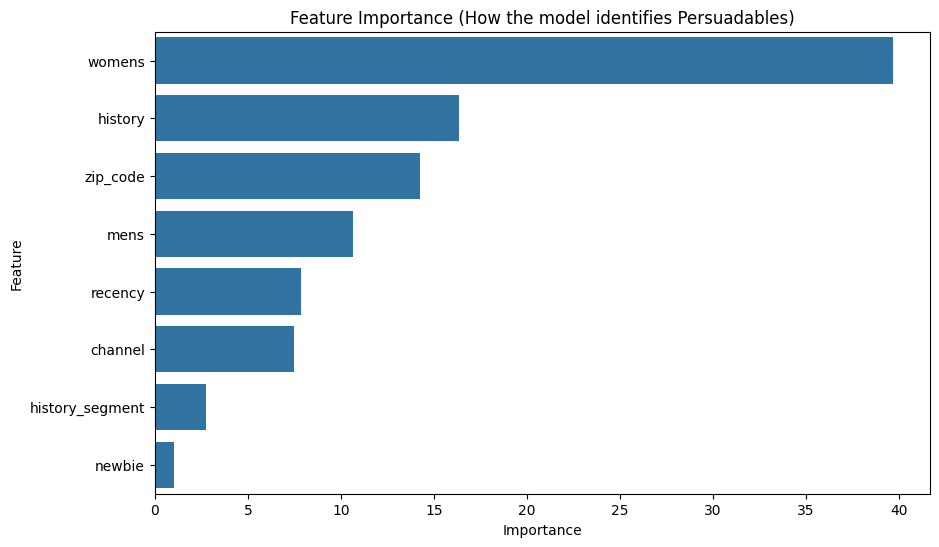

           Feature  Importance
4           womens   39.666489
2          history   16.338445
5         zip_code   14.233508
3             mens   10.628043
0          recency    7.856170
7          channel    7.500794
1  history_segment    2.747041
6           newbie    1.029511


In [45]:
# 1. Get the underlying estimator
# This is the trained CatBoost model
fitted_estimator = ct_model.estimator

# 2. Get the feature importances
# CatBoost provides 'feature_importances_'
importances = fitted_estimator.feature_importances_

# 3. Create a clean DataFrame for viewing
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance (How the model identifies Persuadables)")
plt.show()

print(importance_df)

In [46]:
from sklift.metrics import uplift_at_k
import pandas as pd

k = 0.1

# 1. Calculate for TOP 10% (Using original predictions)
top_train_overall = uplift_at_k(y_train, train_preds, trmnt_train, strategy='overall', k=k)
top_val_overall = uplift_at_k(y_val, val_preds, trmnt_val, strategy='overall', k=k)

# 2. Calculate for BOTTOM 10% (By flipping the sign of the predictions)
# By multiplying by -1, the "lowest" scores become the "highest"
bot_train_overall = uplift_at_k(y_train, -train_preds, trmnt_train, strategy='overall', k=k)
bot_val_overall = uplift_at_k(y_val, -val_preds, trmnt_val, strategy='overall', k=k)

# 3. Create the comparison table
results_df = pd.DataFrame({
    "Segment": ["Top 10% (Original)", "Bottom 10% (Flipped)"],
    "Train Uplift": [top_train_overall, bot_train_overall],
    "Validation Uplift": [top_val_overall, bot_val_overall]
})

print(results_df)

                Segment  Train Uplift  Validation Uplift
0    Top 10% (Original)      0.088113           0.097277
1  Bottom 10% (Flipped)      0.003597           0.007506


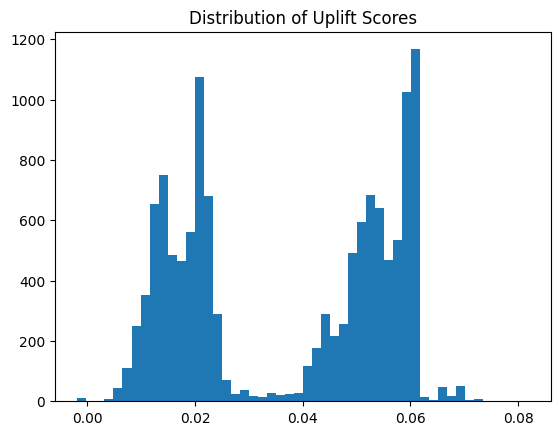

In [47]:
import matplotlib.pyplot as plt
plt.hist(val_preds, bins=50)
plt.title("Distribution of Uplift Scores")
plt.show()